#### __Import Required Libraries__

In [25]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


#### __Load the Dataset__

In [26]:
# Load train and test datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("✓ Dataset loaded successfully!")
print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")

✓ Dataset loaded successfully!
Training data shape: (8693, 14)
Test data shape: (4277, 13)


### ___STEP 2: EXPLORATORY DATA ANALYSIS (EDA) AND PREPROCESSING___

#### __2.1 Basic Dataset Information__

In [27]:
# Display first few rows
print("First 5 rows of training data:")
print("="*80)
train_df.head()

First 5 rows of training data:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [28]:
# Get dataset information
print("Dataset Information:")
print("="*80)
train_df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [29]:
# Statistical summary of numerical features
print("Statistical Summary:")
print("="*80)
train_df.describe()

Statistical Summary:


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


#### __2.2 Understanding Features__

**Feature Descriptions:**
- **PassengerId**: Unique ID for each passenger (format: gggg_pp)
- **HomePlanet**: Planet the passenger departed from (Earth, Europa, Mars)
- **CryoSleep**: Whether passenger was in suspended animation
- **Cabin**: Cabin number (format: deck/num/side)
- **Destination**: Planet the passenger was traveling to
- **Age**: Age of the passenger
- **VIP**: Whether passenger paid for VIP service
- **RoomService, FoodCourt, ShoppingMall, Spa, VRDeck**: Amount billed at each amenity
- **Name**: First and last name
- **Transported**: TARGET VARIABLE - Whether passenger was transported (True/False)

In [30]:
# Check unique values in categorical columns
categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

print("Unique values in categorical columns:")
print("="*80)
for col in categorical_cols:
    print(f"\n{col}:")
    print(train_df[col].value_counts())
    print(f"Missing values: {train_df[col].isnull().sum()}")

Unique values in categorical columns:

HomePlanet:
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64
Missing values: 201

CryoSleep:
CryoSleep
False    5439
True     3037
Name: count, dtype: int64
Missing values: 217

Destination:
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64
Missing values: 182

VIP:
VIP
False    8291
True      199
Name: count, dtype: int64
Missing values: 203


#### __2.3 Target Variable Analysis__

Target Variable (Transported) Distribution:
Transported
True     4378
False    4315
Name: count, dtype: int64

Percentage Transported: 50.36%
Percentage Not Transported: 49.64%


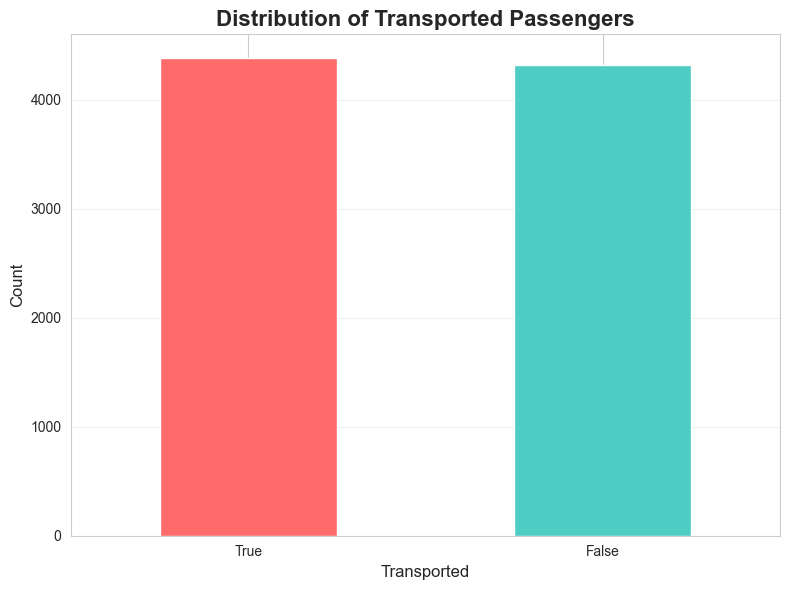


✓ The dataset is balanced (approximately 50-50 split)


In [31]:
# Analyze target variable distribution
print("Target Variable (Transported) Distribution:")
print("="*80)
print(train_df['Transported'].value_counts())
print(f"\nPercentage Transported: {train_df['Transported'].mean()*100:.2f}%")
print(f"Percentage Not Transported: {(1-train_df['Transported'].mean())*100:.2f}%")

# Visualize target distribution
plt.figure(figsize=(8, 6))
train_df['Transported'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.title('Distribution of Transported Passengers', fontsize=16, fontweight='bold')
plt.xlabel('Transported', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ The dataset is balanced (approximately 50-50 split)")

#### __2.4 Missing Values Analysis__

Missing Values Analysis:

      Column  Missing Count  Percentage
   CryoSleep            217    2.496261
ShoppingMall            208    2.392730
         VIP            203    2.335212
  HomePlanet            201    2.312205
        Name            200    2.300702
       Cabin            199    2.289198
      VRDeck            188    2.162660
   FoodCourt            183    2.105142
         Spa            183    2.105142
 Destination            182    2.093639
 RoomService            181    2.082135
         Age            179    2.059128


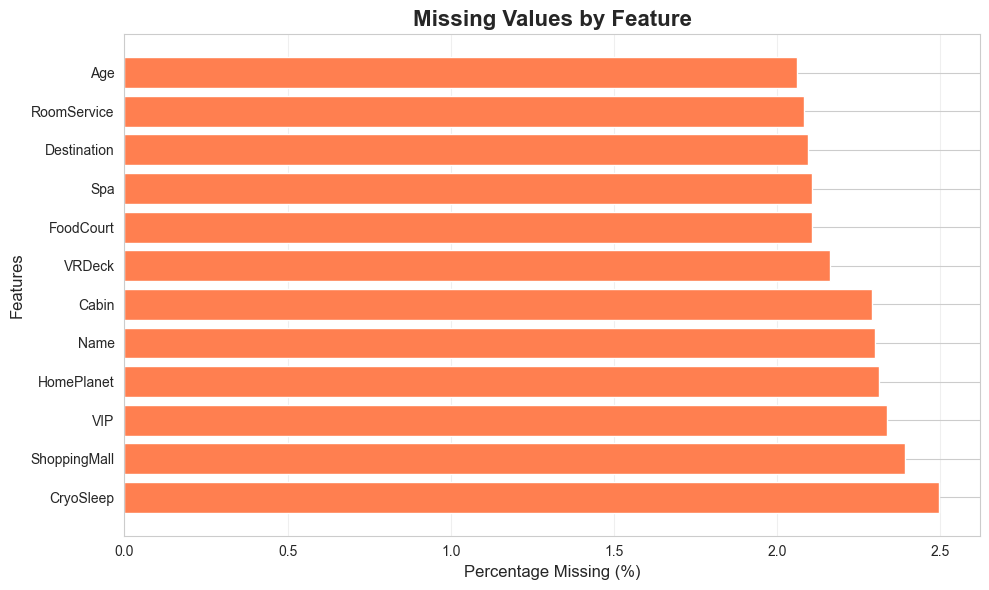

In [32]:
# Analyze missing values
print("Missing Values Analysis:")
print()

missing_train = train_df.isnull().sum()
missing_train_pct = (missing_train / len(train_df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_train.index,
    'Missing Count': missing_train.values,
    'Percentage': missing_train_pct.values
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df.to_string(index=False))

# Visualize missing values
if len(missing_df) > 0:
    plt.figure(figsize=(10, 6))
    plt.barh(missing_df['Column'], missing_df['Percentage'], color='coral')
    plt.xlabel('Percentage Missing (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title('Missing Values by Feature', fontsize=16, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

#### __2.5 Numerical Features Distribution__

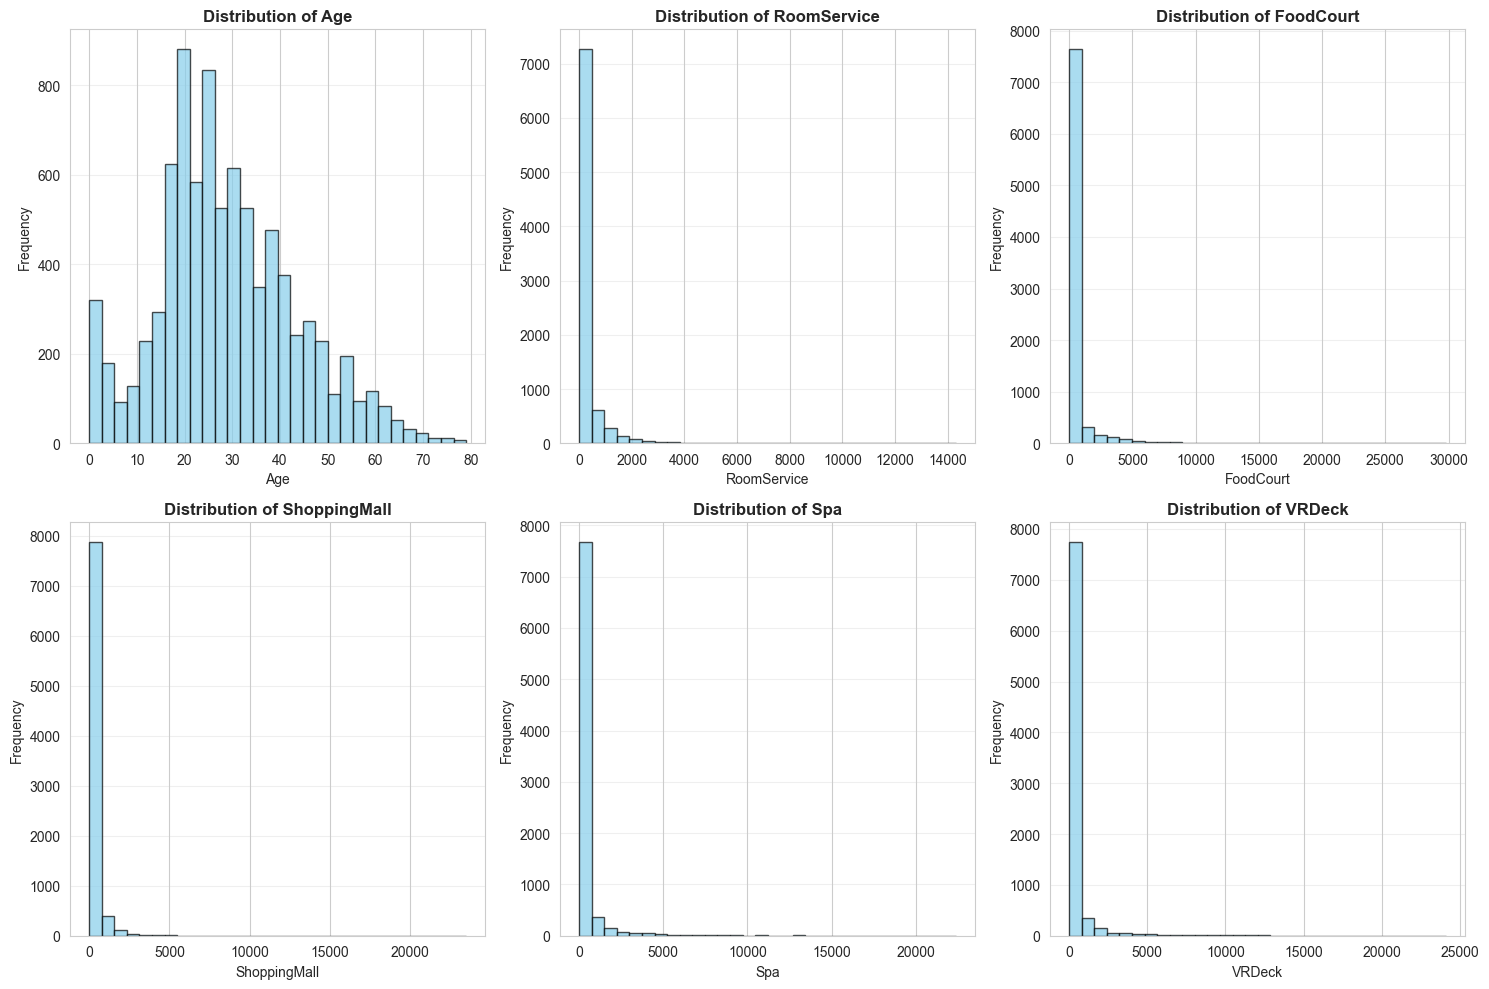

✓ Most spending features are right-skewed (many passengers spend little or nothing)


In [33]:
# Visualize distribution of numerical features
numerical_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    axes[idx].hist(train_df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Most spending features are right-skewed (many passengers spend little or nothing)")

#### __2.6 Categorical Features vs Target__

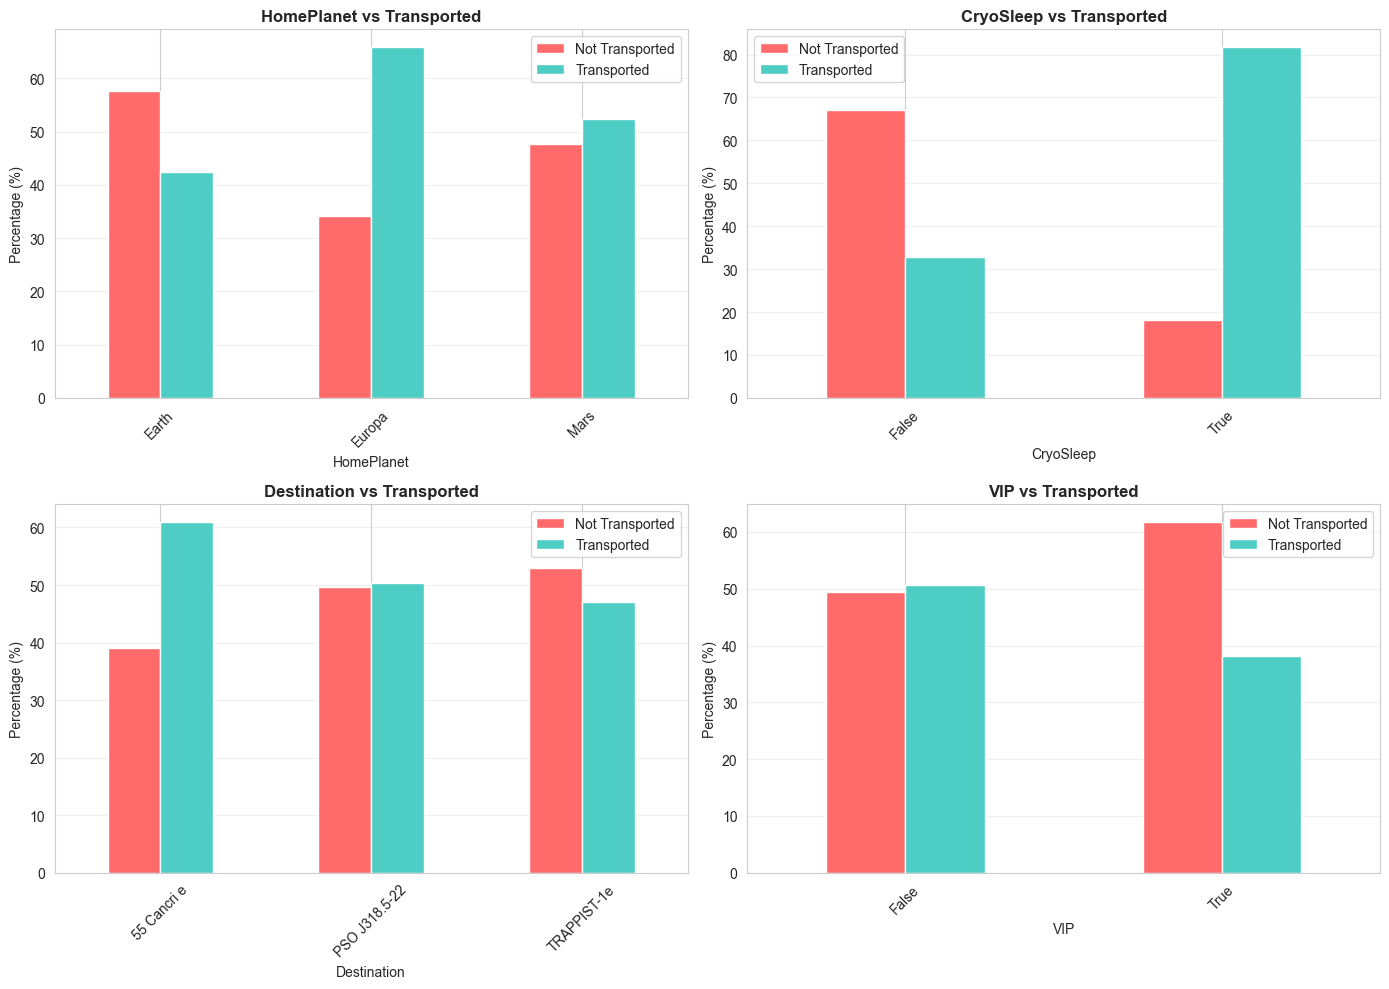

In [34]:
# Analyze relationship between categorical features and target
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_features):
    # Create crosstab
    ct = pd.crosstab(train_df[col], train_df['Transported'], normalize='index') * 100
    
    ct.plot(kind='bar', ax=axes[idx], color=['#FF6B6B', '#4ECDC4'])
    axes[idx].set_title(f'{col} vs Transported', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].legend(['Not Transported', 'Transported'], loc='best')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


#### __2.7 Correlation Analysis__

Correlation with Target Variable (Transported):

Transported     1.000000
CryoSleep       0.404716
HomePlanet      0.107755
FoodCourt       0.046566
ShoppingMall    0.010141
VIP            -0.014260
Age            -0.075026
Destination    -0.104817
VRDeck         -0.207075
Spa            -0.221131
RoomService    -0.244611
Name: Transported, dtype: float64


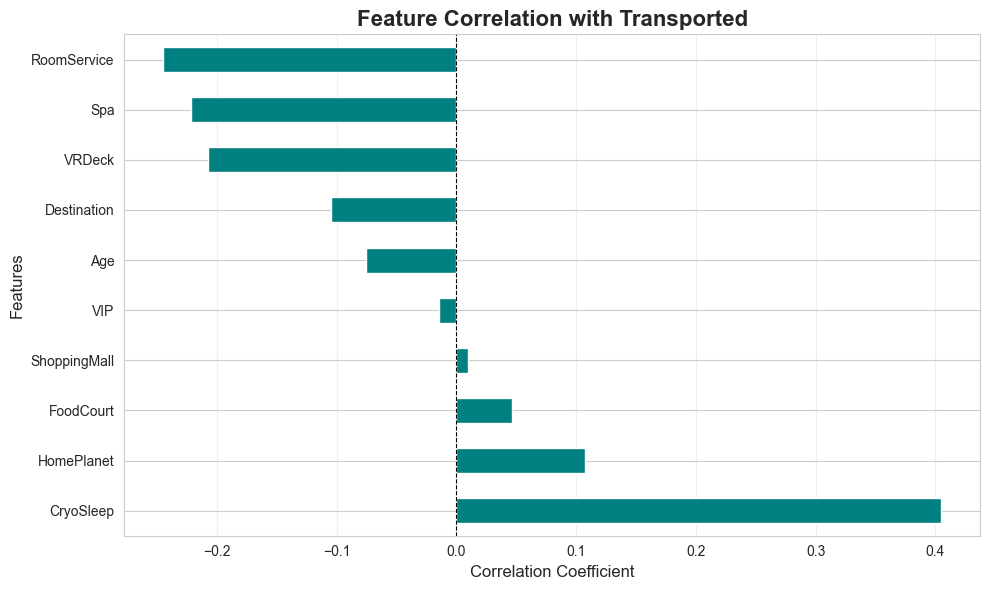

In [35]:
# Calculate correlation with target (for numerical features)
df_corr = train_df.copy()

# Encode categorical variables temporarily for correlation
for col in ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Transported']:
    if col in df_corr.columns:
        le = LabelEncoder()
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Select relevant columns for correlation
corr_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 
             'HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Transported']
correlation = df_corr[corr_cols].corr()['Transported'].sort_values(ascending=False)

print("Correlation with Target Variable (Transported):")
print()
print(correlation)

# Visualize correlation
plt.figure(figsize=(10, 6))
correlation.drop('Transported').plot(kind='barh', color='teal')
plt.title('Feature Correlation with Transported', fontsize=16, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


#### __2.8 Data Preprocessing__ 

In [36]:
# Combine train and test for consistent preprocessing
print("Combining train and test datasets for preprocessing...")
train_len = len(train_df)
y_train = train_df['Transported'].copy()
train_df_copy = train_df.drop('Transported', axis=1)
combined_df = pd.concat([train_df_copy, test_df], axis=0, ignore_index=True)

print(f"✓ Combined dataset shape: {combined_df.shape}")
print(f"✓ Will split back after preprocessing")

Combining train and test datasets for preprocessing...
✓ Combined dataset shape: (12970, 13)
✓ Will split back after preprocessing


In [37]:
# Feature Engineering
print("Performing Feature Engineering...")
print("="*80)

# 1. Extract Group and PersonNumber from PassengerId
combined_df[['Group', 'PersonNumber']] = combined_df['PassengerId'].str.split('_', expand=True)
combined_df['Group'] = combined_df['Group'].astype(int)
combined_df['PersonNumber'] = combined_df['PersonNumber'].astype(int)
print("✓ Extracted Group and PersonNumber from PassengerId")

# 2. Extract Deck, Number, and Side from Cabin
combined_df[['Deck', 'Num', 'Side']] = combined_df['Cabin'].str.split('/', expand=True)
print("✓ Extracted Deck, Num, and Side from Cabin")

# 3. Create GroupSize feature
combined_df['GroupSize'] = combined_df.groupby('Group')['Group'].transform('count')
print("✓ Created GroupSize feature (number of people in each group)")

# 4. Create spending features
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
combined_df['TotalSpending'] = combined_df[spending_cols].sum(axis=1)
combined_df['HasSpending'] = (combined_df['TotalSpending'] > 0).astype(int)
print("✓ Created TotalSpending and HasSpending features")

# 5. Age groups
combined_df['AgeGroup'] = pd.cut(combined_df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                                   labels=['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior'])
print("✓ Created AgeGroup feature")

print("\nNew features created:")
print("  - Group, PersonNumber (from PassengerId)")
print("  - Deck, Num, Side (from Cabin)")
print("  - GroupSize")
print("  - TotalSpending, HasSpending")
print("  - AgeGroup")

Performing Feature Engineering...
✓ Extracted Group and PersonNumber from PassengerId
✓ Extracted Deck, Num, and Side from Cabin
✓ Created GroupSize feature (number of people in each group)
✓ Created TotalSpending and HasSpending features
✓ Created AgeGroup feature

New features created:
  - Group, PersonNumber (from PassengerId)
  - Deck, Num, Side (from Cabin)
  - GroupSize
  - TotalSpending, HasSpending
  - AgeGroup


#### __2.9 Handle Missing Values__

In [38]:
# Handle missing values
print("Handling Missing Values...")
print("="*80)

# Fill numerical features with median
numerical_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpending']
for col in numerical_cols:
    if col in combined_df.columns:
        median_val = combined_df[col].median()
        combined_df[col].fillna(median_val, inplace=True)
        print(f"✓ Filled {col} with median: {median_val:.2f}")

# Fill categorical features with mode
categorical_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'AgeGroup']
for col in categorical_cols:
    if col in combined_df.columns:
        mode_val = combined_df[col].mode()[0]
        combined_df[col].fillna(mode_val, inplace=True)
        print(f"✓ Filled {col} with mode: {mode_val}")

print("\n✓ All missing values handled!")
print(f"Remaining missing values: {combined_df.isnull().sum().sum()}")

Handling Missing Values...
✓ Filled Age with median: 27.00
✓ Filled RoomService with median: 0.00
✓ Filled FoodCourt with median: 0.00
✓ Filled ShoppingMall with median: 0.00
✓ Filled Spa with median: 0.00
✓ Filled VRDeck with median: 0.00
✓ Filled TotalSpending with median: 716.00
✓ Filled HomePlanet with mode: Earth
✓ Filled CryoSleep with mode: False
✓ Filled Destination with mode: TRAPPIST-1e
✓ Filled VIP with mode: False
✓ Filled Deck with mode: F
✓ Filled Side with mode: S
✓ Filled AgeGroup with mode: Adult

✓ All missing values handled!
Remaining missing values: 892


#### __2.10 Encode Categorical Variables__

In [39]:
# Select features for modeling
features_to_use = ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 
                   'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
                   'Deck', 'Side', 'GroupSize', 'TotalSpending', 'HasSpending']

# Create a copy for encoding
df_encoded = combined_df[features_to_use].copy()

# Label encode categorical variables
print("Encoding Categorical Variables...")
print("="*80)


label_encoders = {}
categorical_to_encode = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

for col in categorical_to_encode:
    if col in df_encoded.columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le
        print(f"✓ Encoded {col}: {len(le.classes_)} unique values")

print("\n✓ All categorical variables encoded!")

Encoding Categorical Variables...
✓ Encoded HomePlanet: 3 unique values
✓ Encoded CryoSleep: 2 unique values
✓ Encoded Destination: 3 unique values
✓ Encoded VIP: 2 unique values
✓ Encoded Deck: 8 unique values
✓ Encoded Side: 2 unique values

✓ All categorical variables encoded!


#### __2.11 Split Back to Train and Test & Scale Features__

In [40]:
# Split back to train and test
X_train = df_encoded[:train_len]
X_test = df_encoded[train_len:]

print("Dataset Split:")
print("="*80)
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")

# Feature Scaling
print("\nScaling Features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✓ Features scaled using StandardScaler")

print("\n✓ Data preprocessing completed successfully!")

Dataset Split:
Training features shape: (8693, 15)
Test features shape: (4277, 15)
Training labels shape: (8693,)

Scaling Features...
✓ Features scaled using StandardScaler

✓ Data preprocessing completed successfully!



### ___STEP 3: TRAIN CLASSIFICATION MODEL TO PREDICT SURVIVAL STATUS___

#### __3.1 Create Train-Validation Split__

In [41]:
# Split training data for validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Data Split for Training:")
print("="*80)
print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val_split.shape}")
print(f"\nClass distribution in training set:")
print(y_train_split.value_counts(normalize=True))
print(f"\nClass distribution in validation set:")
print(y_val_split.value_counts(normalize=True))

Data Split for Training:
Training set: (6954, 15)
Validation set: (1739, 15)

Class distribution in training set:
Transported
True     0.503595
False    0.496405
Name: proportion, dtype: float64

Class distribution in validation set:
Transported
True     0.503738
False    0.496262
Name: proportion, dtype: float64


#### __3.2 Train Multiple Models__

In [42]:
# Define models to train
print("Training Multiple Classification Models...")
print("="*80)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15, 
                                            min_samples_split=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                     learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Training: {name}")
    print(f"{'='*80}")
    
    # Train the model
    model.fit(X_train_split, y_train_split)
    print("✓ Model trained")
    
    # Make predictions
    y_pred_train = model.predict(X_train_split)
    y_pred_val = model.predict(X_val_split)
    
    # Calculate accuracy
    train_acc = accuracy_score(y_train_split, y_pred_train)
    val_acc = accuracy_score(y_val_split, y_pred_val)
    
    # Cross-validation
    print("Performing 5-fold cross-validation...")
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    # Store results
    results[name] = {
        'model': model,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'cv_scores': cv_scores
    }
    
    # Print results
    print(f"\nResults for {name}:")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Validation Accuracy: {val_acc:.4f}")
    print(f"  CV Mean Accuracy: {cv_scores.mean():.4f}")
    print(f"  CV Std: {cv_scores.std():.4f}")
    print(f"  CV Scores: {cv_scores}")

print("\n" + "="*80)
print("✓ All models trained successfully!")
print("="*80)

Training Multiple Classification Models...

Training: Logistic Regression
✓ Model trained
Performing 5-fold cross-validation...

Results for Logistic Regression:
  Train Accuracy: 0.7921
  Validation Accuracy: 0.7884
  CV Mean Accuracy: 0.7895
  CV Std: 0.0099
  CV Scores: [0.77343301 0.78608396 0.78895917 0.79631761 0.80264672]

Training: Random Forest
✓ Model trained
Performing 5-fold cross-validation...

Results for Random Forest:
  Train Accuracy: 0.8871
  Validation Accuracy: 0.8022
  CV Mean Accuracy: 0.7937
  CV Std: 0.0108
  CV Scores: [0.77918344 0.78205865 0.80218516 0.80149597 0.80379747]

Training: Gradient Boosting
✓ Model trained
Performing 5-fold cross-validation...

Results for Gradient Boosting:
  Train Accuracy: 0.8944
  Validation Accuracy: 0.8074
  CV Mean Accuracy: 0.7978
  CV Std: 0.0101
  CV Scores: [0.78435883 0.79240943 0.79585969 0.81472957 0.80149597]

✓ All models trained successfully!


#### __3.3 Compare Model Performance__

Model Comparison:
              Model  Train Accuracy  Validation Accuracy  CV Mean   CV Std
Logistic Regression        0.792062             0.788384 0.789488 0.009894
      Random Forest        0.887115             0.802185 0.793744 0.010779
  Gradient Boosting        0.894449             0.807361 0.797771 0.010137


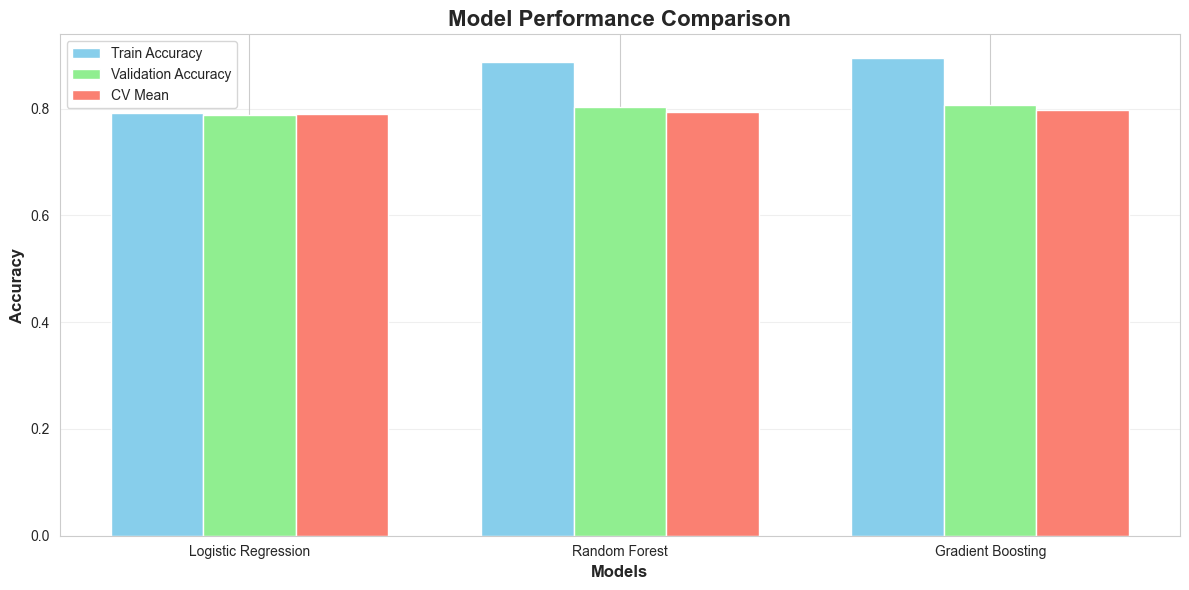


✓ Best Model: Gradient Boosting
  Validation Accuracy: 0.8074


In [43]:
# Create comparison dataframe
print("Model Comparison:")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy': [results[m]['train_accuracy'] for m in results.keys()],
    'Validation Accuracy': [results[m]['val_accuracy'] for m in results.keys()],
    'CV Mean': [results[m]['cv_mean'] for m in results.keys()],
    'CV Std': [results[m]['cv_std'] for m in results.keys()]
})

print(comparison_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df))
width = 0.25

ax.bar(x - width, comparison_df['Train Accuracy'], width, label='Train Accuracy', color='skyblue')
ax.bar(x, comparison_df['Validation Accuracy'], width, label='Validation Accuracy', color='lightgreen')
ax.bar(x + width, comparison_df['CV Mean'], width, label='CV Mean', color='salmon')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Select best model
best_model_name = comparison_df.loc[comparison_df['Validation Accuracy'].idxmax(), 'Model']
best_model = results[best_model_name]['model']

print(f"\n{'='*80}")
print(f"✓ Best Model: {best_model_name}")
print(f"  Validation Accuracy: {results[best_model_name]['val_accuracy']:.4f}")
print(f"{'='*80}")


### __STEP 4: EVALUATE AND IMPROVE MODEL PERFORMANCE__

#### __4.1 Detailed Evaluation of Best Model__

In [44]:
# Detailed evaluation
print(f"Detailed Evaluation of {best_model_name}")
print("="*80)

y_pred_val = best_model.predict(X_val_split)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val_split, y_pred_val, 
                          target_names=['Not Transported', 'Transported']))

# Confusion Matrix
cm = confusion_matrix(y_val_split, y_pred_val)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

Detailed Evaluation of Gradient Boosting

Classification Report:
                 precision    recall  f1-score   support

Not Transported       0.81      0.79      0.80       863
    Transported       0.80      0.82      0.81       876

       accuracy                           0.81      1739
      macro avg       0.81      0.81      0.81      1739
   weighted avg       0.81      0.81      0.81      1739


Confusion Matrix:
[[685 178]
 [157 719]]

True Negatives: 685
False Positives: 178
False Negatives: 157
True Positives: 719


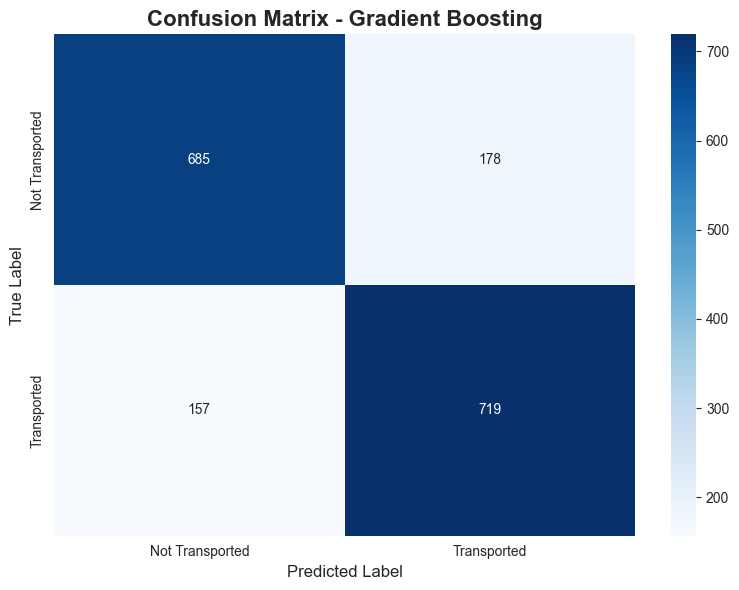

In [45]:
# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Not Transported', 'Transported'],
            yticklabels=['Not Transported', 'Transported'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

#### __4.2 Feature Importance Analysis__

Feature Importance Analysis:

Top 15 Most Important Features:
      Feature  Importance
TotalSpending    0.238697
  HasSpending    0.172502
    FoodCourt    0.104106
 ShoppingMall    0.080753
          Spa    0.069661
       VRDeck    0.067270
   HomePlanet    0.061387
          Age    0.053977
  RoomService    0.047992
         Deck    0.045187
    CryoSleep    0.021459
         Side    0.014750
    GroupSize    0.013349
  Destination    0.008099
          VIP    0.000812


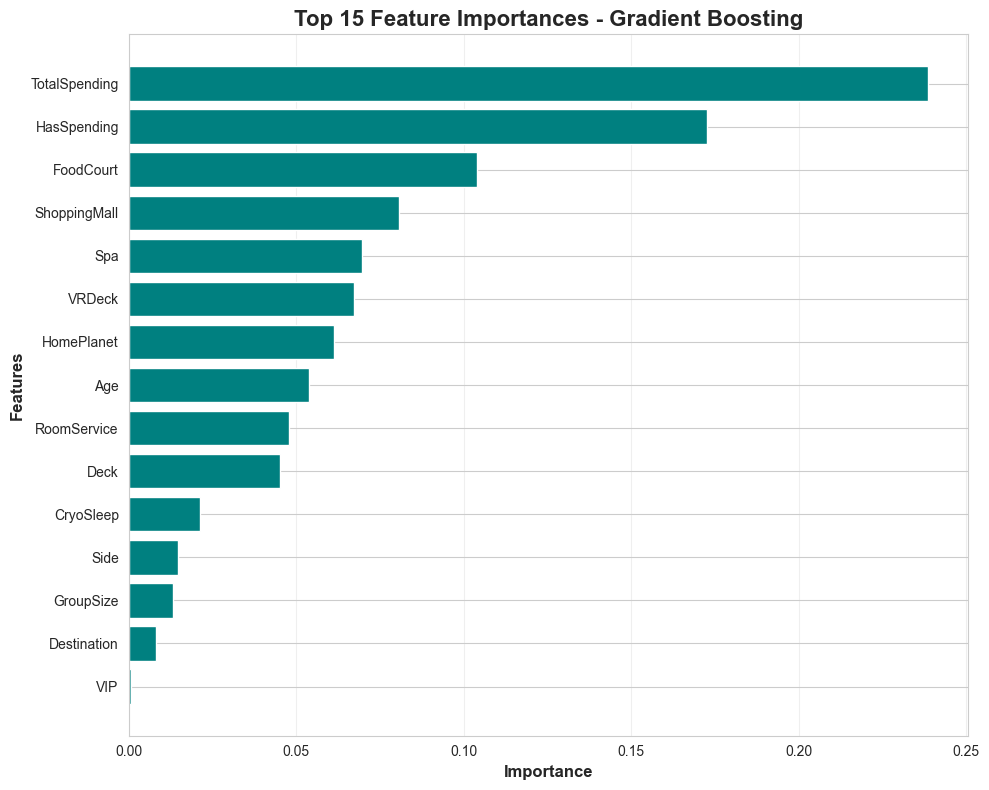


✓ Top features identified!


In [46]:
# Feature Importance (for tree-based models)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    print("Feature Importance Analysis:")
    print("="*80)
    
    feature_importance = pd.DataFrame({
        'Feature': features_to_use,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 15 Most Important Features:")
    print(feature_importance.head(15).to_string(index=False))
    
    # Visualize feature importance
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['Importance'], color='teal')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.title(f'Top 15 Feature Importances - {best_model_name}', 
              fontsize=16, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Top features identified!")
else:
    print(f"Feature importance not available for {best_model_name}")

#### __4.3 Hyperparameter Tuning (Optional - Improve Performance)__

In [47]:
# Hyperparameter tuning for the best model
print("Hyperparameter Tuning:")
print("="*80)
print("Note: This may take a few minutes...\n")

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20],
        'min_samples_split': [5, 10, 15]
    }
    base_model = RandomForestClassifier(random_state=42)
    
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }
    base_model = GradientBoostingClassifier(random_state=42)
    
else:
    param_grid = {
        'C': [0.1, 1, 10],
        'max_iter': [1000, 2000]
    }
    base_model = LogisticRegression(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(base_model, param_grid, cv=5, 
                          scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print("\n✓ Hyperparameter tuning completed!")
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# Use the best model
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_val_split)
tuned_acc = accuracy_score(y_val_split, y_pred_tuned)

print(f"\nTuned Model Validation Accuracy: {tuned_acc:.4f}")
print(f"Original Model Validation Accuracy: {results[best_model_name]['val_accuracy']:.4f}")
print(f"Improvement: {(tuned_acc - results[best_model_name]['val_accuracy']):.4f}")

# Use tuned model if it's better
if tuned_acc > results[best_model_name]['val_accuracy']:
    print("\n✓ Using tuned model for final predictions!")
    final_model = tuned_model
else:
    print("\n✓ Original model performs better, using original model!")
    final_model = best_model

Hyperparameter Tuning:
Note: This may take a few minutes...

Fitting 5 folds for each of 27 candidates, totalling 135 fits

✓ Hyperparameter tuning completed!

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best CV Score: 0.8011

Tuned Model Validation Accuracy: 0.8649
Original Model Validation Accuracy: 0.8074
Improvement: 0.0575

✓ Using tuned model for final predictions!


#### __4.4 Final Model Training on Full Dataset__

In [48]:
# Train final model on complete training data
print("Training Final Model on Complete Training Data:")
print("="*80)

final_model.fit(X_train_scaled, y_train)
print("✓ Final model trained on all training data")

# Final training accuracy
y_train_pred = final_model.predict(X_train_scaled)
final_train_acc = accuracy_score(y_train, y_train_pred)
print(f"\nFinal Training Accuracy: {final_train_acc:.4f}")

Training Final Model on Complete Training Data:
✓ Final model trained on all training data

Final Training Accuracy: 0.8522


#### __4.5 Make Predictions on Test Set__

In [49]:
# Make predictions on test set
print("Making Predictions on Test Set:")
print("="*80)

test_predictions = final_model.predict(X_test_scaled)
print(f"✓ Predictions completed for {len(test_predictions)} test samples")

# Analyze predictions
print(f"\nPrediction Distribution:")
print(f"  Predicted as Transported: {test_predictions.sum()} ({test_predictions.mean()*100:.2f}%)")
print(f"  Predicted as Not Transported: {len(test_predictions) - test_predictions.sum()} ({(1-test_predictions.mean())*100:.2f}%)")

Making Predictions on Test Set:
✓ Predictions completed for 4277 test samples

Prediction Distribution:
  Predicted as Transported: 2277 (53.24%)
  Predicted as Not Transported: 2000 (46.76%)


#### __4.6 Create Submission File__

In [50]:
# Create submission file
print("Creating Submission File:")
print("="*80)

submission_df = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': test_predictions
})

# Save to CSV
submission_df.to_csv('submission.csv', index=False)
print("✓ Submission file created: submission.csv")


Creating Submission File:
✓ Submission file created: submission.csv
